In [362]:
from statistics import mean
from statistics import stdev
import pandas as pd
import pandasql as ps
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prettytable import PrettyTable
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import seaborn as sns
from scipy.stats import poisson
from datetime import datetime
import math
import matplotlib.ticker as ticker

In [363]:
# df_1_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_1.csv')
# df_2_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_2.csv')
# df_3_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_3.csv')
# df_4_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_4.csv')
df_1_layer = pd.read_csv('data/Output_with_layers_1.csv')
df_2_layer = pd.read_csv('data/Output_with_layers_2.csv')
df_3_layer = pd.read_csv('data/Output_with_layers_3.csv')
df_4_layer = pd.read_csv('data/Output_with_layers_4.csv')
df_btc = pd.read_csv('data/BTC_Output.csv')
df_digishield = pd.read_csv('data/DigiShield_Output.csv')
df_lwma = pd.read_csv('data/LWMA_Output.csv')

df_1_layer['timestamp'] -= 62168450400
df_1_layer['median_time'] = pd.to_datetime(df_1_layer['timestamp'], unit='s')
df_2_layer['timestamp'] -= 62168450400
df_2_layer['median_time'] = pd.to_datetime(df_2_layer['timestamp'], unit='s')
df_3_layer['timestamp'] -= 62168450400
df_3_layer['median_time'] = pd.to_datetime(df_3_layer['timestamp'], unit='s')
df_4_layer['timestamp'] -= 62168450400
df_4_layer['median_time'] = pd.to_datetime(df_4_layer['timestamp'], unit='s')
df_btc['timestamp'] -= 62168450400
df_btc['median_time'] = pd.to_datetime(df_btc['timestamp'], unit='s')
df_digishield['timestamp'] -= 62168450400
df_digishield['median_time'] = pd.to_datetime(df_digishield['timestamp'], unit='s')
df_lwma['timestamp'] -= 62168450400
df_lwma['median_time'] = pd.to_datetime(df_lwma['timestamp'], unit='s')

### Block times

In [364]:
import pandas as pd

# === Summary Stats ===
for i, df in enumerate([df_1_layer, df_2_layer, df_3_layer, df_4_layer, df_btc, df_digishield, df_lwma], 1):
    if i == 5:
        print("BTC DAA:")
    elif i == 6:
        print("DigiShield DAA:")
    elif i == 7:
        print("LWMA DAA:")
    else:
        print(f"with {i} layer{'s' if i > 1 else ''}:")
    print("mean:", df['block_time'].mean())
    print("stdev:", df['block_time'].std())

# === Sanity Check ===
for df in [df_1_layer, df_2_layer, df_3_layer, df_4_layer, df_btc, df_digishield, df_lwma]:
    df['secondary_block_time'] = pd.to_datetime(df['median_time']).diff().dt.total_seconds().fillna(0)

print(df_1_layer['block_time'][1:].equals(df_1_layer['secondary_block_time'][1:]))
print(df_2_layer['block_time'][1:].equals(df_2_layer['secondary_block_time'][1:]))
print(df_3_layer['block_time'][1:].equals(df_3_layer['secondary_block_time'][1:]))
print(df_4_layer['block_time'][1:].equals(df_4_layer['secondary_block_time'][1:]))
print(df_btc['block_time'][1:].equals(df_btc['secondary_block_time'][1:]))
print(df_digishield['block_time'][1:].equals(df_digishield['secondary_block_time'][1:]))
print(df_lwma['block_time'][1:].equals(df_lwma['secondary_block_time'][1:]))
# === Average Block Time per Day ===
def avg_block_time_per_day(df):
    df['median_time'] = pd.to_datetime(df['median_time'])
    df['day'] = df['median_time'].dt.floor('D')
    return df.groupby('day')['block_time'].mean().reset_index(name='avg_block_time')

q_res_1_layer_avg_block_time = avg_block_time_per_day(df_1_layer)
q_res_2_layer_avg_block_time = avg_block_time_per_day(df_2_layer)
q_res_3_layer_avg_block_time = avg_block_time_per_day(df_3_layer)
q_res_4_layer_avg_block_time = avg_block_time_per_day(df_4_layer)
q_res_btc_avg_block_time = avg_block_time_per_day(df_btc)
q_res_digishield_avg_block_time = avg_block_time_per_day(df_digishield)
q_res_lwma_avg_block_time = avg_block_time_per_day(df_lwma)

# === Hourly Record Count ===
def hourly_record_count(df):
    df['median_time'] = pd.to_datetime(df['median_time'])
    df['hour'] = df['median_time'].dt.floor('h')
    return df.groupby('hour').size().reset_index(name='record_count')

q_res_1_layer_hour_count = hourly_record_count(df_1_layer)
q_res_2_layer_hour_count = hourly_record_count(df_2_layer)
q_res_3_layer_hour_count = hourly_record_count(df_3_layer)
q_res_4_layer_hour_count = hourly_record_count(df_4_layer)
q_res_btc_hour_count = hourly_record_count(df_btc)
q_res_digishield_hour_count = hourly_record_count(df_digishield)
q_res_lwma_hour_count = hourly_record_count(df_lwma)

# === Fill Missing Hours ===
min_hour = q_res_1_layer_hour_count['hour'].min()
max_hour = q_res_1_layer_hour_count['hour'].max()
complete_range = pd.date_range(start=min_hour, end=max_hour, freq='h')
complete_df = pd.DataFrame({'hour': complete_range})

def fill_missing_hours(df):
    return pd.merge(complete_df, df, on='hour', how='left').fillna({'record_count': 0})

q_res_1_layer_hour_count = fill_missing_hours(q_res_1_layer_hour_count)
q_res_2_layer_hour_count = fill_missing_hours(q_res_2_layer_hour_count)
q_res_3_layer_hour_count = fill_missing_hours(q_res_3_layer_hour_count)
q_res_4_layer_hour_count = fill_missing_hours(q_res_4_layer_hour_count)
q_res_btc_hour_count = fill_missing_hours(q_res_btc_hour_count)
q_res_digishield_hour_count = fill_missing_hours(q_res_digishield_hour_count)
q_res_lwma_hour_count = fill_missing_hours(q_res_lwma_hour_count)

with 1 layer:
mean: 595.1936376324363
stdev: 597.492490408276
with 2 layers:
mean: 599.9934870025239
stdev: 602.242714452307
with 3 layers:
mean: 600.0015970796259
stdev: 604.3102938832304
with 4 layers:
mean: 599.983306003137
stdev: 604.0863531030222
BTC DAA:
mean: 597.1955602024391
stdev: 598.3861528683531
DigiShield DAA:
mean: 600.5629296769067
stdev: 610.9588429544889
LWMA DAA:
mean: 601.5604405292642
stdev: 612.2969408390337
True
True
True
True
True
True
True


### Block time distributions

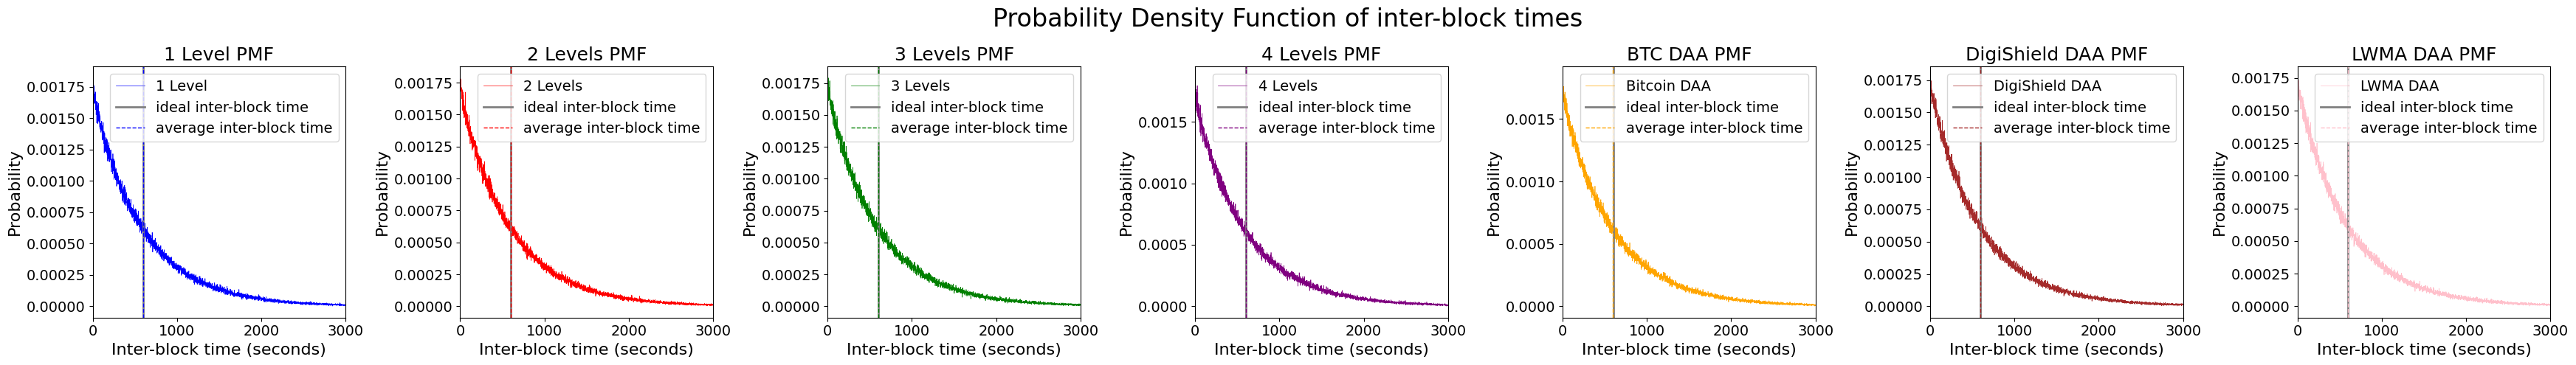

In [365]:
pdf_block_time_1_layer = df_1_layer['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_2_layer = df_2_layer['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_3_layer = df_3_layer['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_4_layer = df_4_layer['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_btc = df_btc['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_digishield = df_digishield['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_lwma = df_lwma['block_time'].value_counts(normalize=True).sort_index()

fig, axs = plt.subplots(1, 7, figsize=(35, 5))

axs[0].plot(pdf_block_time_1_layer.index, pdf_block_time_1_layer.values, color='blue', label='1 Level', linewidth=0.5)
axs[0].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[0].axvline(df_1_layer['block_time'].mean(), color='blue', linestyle='--', linewidth=1, label='average inter-block time')
axs[0].set_title('1 Level PMF', fontsize=18)
axs[0].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[0].set_ylabel('Probability', fontsize=16)
axs[0].set_xlim(0, 3000)
axs[0].legend(fontsize=14)
axs[0].tick_params(axis='both', which='major', labelsize=14)

axs[1].plot(pdf_block_time_2_layer.index, pdf_block_time_2_layer.values, color='red', label='2 Levels', linewidth=0.5)
axs[1].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[1].axvline(df_2_layer['block_time'].mean(), color='red', linestyle='--', linewidth=1, label='average inter-block time')
axs[1].set_title('2 Levels PMF', fontsize=18)
axs[1].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[1].set_ylabel('Probability', fontsize=16)
axs[1].set_xlim(0, 3000)
axs[1].legend(fontsize=14)
axs[1].tick_params(axis='both', which='major', labelsize=14)

axs[2].plot(pdf_block_time_3_layer.index, pdf_block_time_3_layer.values, color='green', label='3 Levels', linewidth=0.5)
axs[2].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[2].axvline(df_3_layer['block_time'].mean(), color='green', linestyle='--', linewidth=1, label='average inter-block time')
axs[2].set_title('3 Levels PMF', fontsize=18)
axs[2].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[2].set_ylabel('Probability', fontsize=16)
axs[2].set_xlim(0, 3000)
axs[2].legend(fontsize=14)
axs[2].tick_params(axis='both', which='major', labelsize=14)

axs[3].plot(pdf_block_time_4_layer.index, pdf_block_time_4_layer.values, color='purple', label='4 Levels', linewidth=0.5)
axs[3].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[3].axvline(df_4_layer['block_time'].mean(), color='purple', linestyle='--', linewidth=1, label='average inter-block time')
axs[3].set_title('4 Levels PMF', fontsize=18)
axs[3].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[3].set_ylabel('Probability', fontsize=16)
axs[3].set_xlim(0, 3000)
axs[3].legend(fontsize=14)
axs[3].tick_params(axis='both', which='major', labelsize=14)

axs[4].plot(pdf_block_time_btc.index, pdf_block_time_btc.values, color='orange', label='Bitcoin DAA', linewidth=0.5)
axs[4].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[4].axvline(df_btc['block_time'].mean(), color='orange', linestyle='--', linewidth=1, label='average inter-block time')
axs[4].set_title('BTC DAA PMF', fontsize=18)
axs[4].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[4].set_ylabel('Probability', fontsize=16)
axs[4].set_xlim(0, 3000)
axs[4].legend(fontsize=14)
axs[4].tick_params(axis='both', which='major', labelsize=14)

axs[5].plot(pdf_block_time_digishield.index, pdf_block_time_digishield.values, color='brown', label='DigiShield DAA', linewidth=0.5)
axs[5].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[5].axvline(df_digishield['block_time'].mean(), color='brown', linestyle='--', linewidth=1, label='average inter-block time')
axs[5].set_title('DigiShield DAA PMF', fontsize=18)
axs[5].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[5].set_ylabel('Probability', fontsize=16)
axs[5].set_xlim(0, 3000)
axs[5].legend(fontsize=14)
axs[5].tick_params(axis='both', which='major', labelsize=14)

axs[6].plot(pdf_block_time_lwma.index, pdf_block_time_lwma.values, color='pink', label='LWMA DAA', linewidth=0.5)
axs[6].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[6].axvline(df_lwma['block_time'].mean(), color='pink', linestyle='--', linewidth=1, label='average inter-block time')
axs[6].set_title('LWMA DAA PMF', fontsize=18)
axs[6].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[6].set_ylabel('Probability', fontsize=16)
axs[6].set_xlim(0, 3000)
axs[6].legend(fontsize=14)
axs[6].tick_params(axis='both', which='major', labelsize=14)

fig.suptitle('Probability Density Function of inter-block times', fontsize=24)
plt.tight_layout()
plt.show()

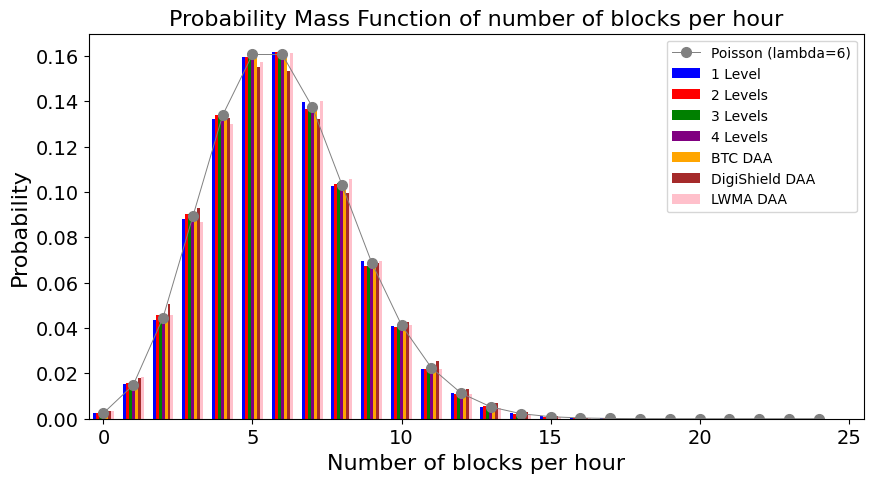

In [366]:
pdf_1_layer = q_res_1_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_2_layer = q_res_2_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_3_layer = q_res_3_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_4_layer = q_res_4_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_btc = q_res_btc_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_digishield = q_res_digishield_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_lwma = q_res_lwma_hour_count['record_count'].value_counts(normalize=True).sort_index()
aligned_data_layers = pd.DataFrame({
    '1 Layer': pdf_1_layer,
    '2 Layers': pdf_2_layer,
    '3 Layers': pdf_3_layer,
    '4 Layers': pdf_4_layer,
    'BTC DAA': pdf_btc,
    'DigiShield DAA': pdf_digishield,
    'LWMA DAA': pdf_lwma
}).fillna(0)

aligned_data_layers = aligned_data_layers[aligned_data_layers.index <= 25]

x_lim = 25
width = 0.10
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
x_positions = np.arange(len(aligned_data_layers))

axs.plot(np.arange(0, x_lim), poisson.pmf(np.arange(0, x_lim), 6), color='gray', label='Poisson (lambda=6)', marker='o', markersize=7, linewidth=0.7)
axs.bar(x_positions - 3 * width, aligned_data_layers['1 Layer'].values, width=width, color='blue', label='1 Level')
axs.bar(x_positions - 2 * width, aligned_data_layers['2 Layers'].values, width=width, color='red', label='2 Levels')
axs.bar(x_positions - 1 * width, aligned_data_layers['3 Layers'].values, width=width, color='green', label='3 Levels')
axs.bar(x_positions, aligned_data_layers['4 Layers'].values, width=width, color='purple', label='4 Levels')
axs.bar(x_positions + 1 * width, aligned_data_layers['BTC DAA'].values, width=width, color='orange', label='BTC DAA')
axs.bar(x_positions + 2 * width, aligned_data_layers['DigiShield DAA'].values, width=width, color='brown', label='DigiShield DAA')
axs.bar(x_positions + 3 * width, aligned_data_layers['LWMA DAA'].values, width=width, color='pink', label='LWMA DAA')
axs.set_xlim(-0.5, len(x_positions) - 0.5)
axs.legend()
axs.set_title('Probability Mass Function of number of blocks per hour', fontsize=16)
axs.set_xlabel('Number of blocks per hour', fontsize=16)
axs.set_ylabel('Probability', fontsize=16)
axs.tick_params(axis='both', which='major', labelsize=14)

tick_positions = np.arange(0, len(aligned_data_layers), 5)
axs.set_xticks(tick_positions)
axs.set_xticklabels(aligned_data_layers.index[tick_positions].astype(int))

plt.show()

### Autocorrelation

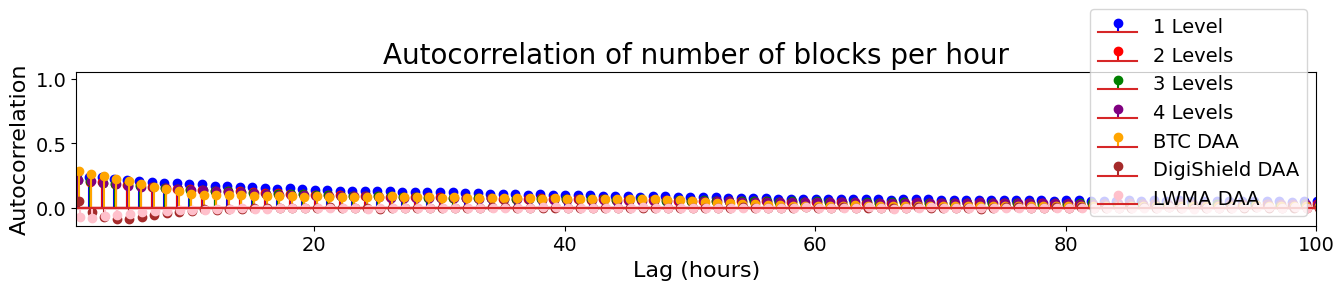

In [367]:
x_lim = 100

acf_values_1_layer = acf(q_res_1_layer_hour_count['record_count'], nlags=x_lim)
acf_values_2_layer = acf(q_res_2_layer_hour_count['record_count'], nlags=x_lim)
acf_values_3_layer = acf(q_res_3_layer_hour_count['record_count'], nlags=x_lim)
acf_values_4_layer = acf(q_res_4_layer_hour_count['record_count'], nlags=x_lim)
acf_values_btc = acf(q_res_btc_hour_count['record_count'], nlags=x_lim)
acf_values_digishield = acf(q_res_digishield_hour_count['record_count'], nlags=x_lim)
acf_values_lwma = acf(q_res_lwma_hour_count['record_count'], nlags=x_lim)

lags = np.arange(0, x_lim + 1)
width = 0.15
plt.stem(lags + 0.25 * width, acf_values_1_layer, label='1 Level', linefmt='blue')
plt.stem(lags + 0.5 * width, acf_values_2_layer, label='2 Levels', linefmt='red')
plt.stem(lags + 0.75 * width, acf_values_3_layer, label='3 Levels', linefmt='green')
plt.stem(lags + width, acf_values_4_layer, label='4 Levels', linefmt='purple')
plt.stem(lags + 1.25 * width, acf_values_btc, label='BTC DAA', linefmt='orange')
plt.stem(lags + 1.5 * width, acf_values_digishield, label='DigiShield DAA', linefmt='brown')
plt.stem(lags + 1.75 * width, acf_values_lwma, label='LWMA DAA', linefmt='pink')
plt.title('Autocorrelation of number of blocks per hour', fontsize=20)
plt.xlabel('Lag (hours)', fontsize=16)
plt.ylabel('Autocorrelation', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gcf().set_size_inches(16, 2)
plt.legend(fontsize=14 ,loc='lower right')
# plt.ylim(min(min(acf_values_1_layer[1:]), min(acf_values_2_layer[1:]), min(acf_values_3_layer[1:]), min(acf_values_4_layer[1:])) * 1.1, 
        #  max(max(acf_values_1_layer[1:]), max(acf_values_2_layer[1:]), max(acf_values_3_layer[1:]), max(acf_values_4_layer[1:])) * 1.1)
plt.xlim(1, x_lim)
plt.show()

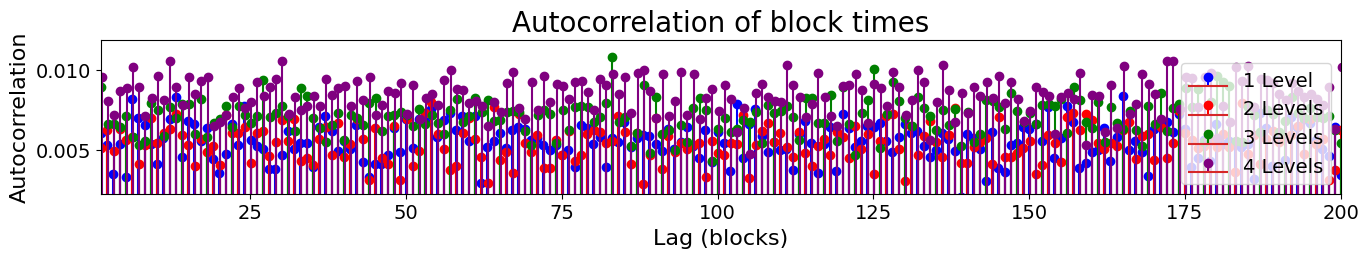

In [ ]:
x_lim = 200

acf_values_1_layer = acf(df_1_layer['block_time'], nlags=x_lim)
acf_values_2_layer = acf(df_2_layer['block_time'], nlags=x_lim)
acf_values_3_layer = acf(df_3_layer['block_time'], nlags=x_lim)
acf_values_4_layer = acf(df_4_layer['block_time'], nlags=x_lim)
acf_values_btc = acf(q_res_btc_hour_count['record_count'], nlags=x_lim)
acf_values_digishield = acf(q_res_digishield_hour_count['record_count'], nlags=x_lim)
acf_values_lwma = acf(q_res_lwma_hour_count['record_count'], nlags=x_lim)

lags = np.arange(0, x_lim + 1)
width = 0.15
plt.stem(lags + 0.25 * width, acf_values_1_layer, label='1 Level', linefmt='blue')
plt.stem(lags + 0.5 * width, acf_values_2_layer, label='2 Levels', linefmt='red')
plt.stem(lags + 0.75 * width, acf_values_3_layer, label='3 Levels', linefmt='green')
plt.stem(lags + width, acf_values_4_layer, label='4 Levels', linefmt='purple')
plt.stem(lags + 1.25 * width, acf_values_btc, label='BTC DAA', linefmt='orange')
plt.stem(lags + 1.5 * width, acf_values_digishield, label='DigiShield DAA', linefmt='brown')
plt.stem(lags + 1.75 * width, acf_values_lwma, label='LWMA DAA', linefmt='pink')
plt.title('Autocorrelation of block times', fontsize=20)
plt.xlabel('Lag (blocks)', fontsize=16)
plt.ylabel('Autocorrelation', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gcf().set_size_inches(16, 2)
plt.legend(fontsize=14, loc='lower right')
# plt.ylim(min(min(acf_values_1_layer[1:]), min(acf_values_2_layer[1:]), min(acf_values_3_layer[1:]), min(acf_values_4_layer[1:])) * 1.1, 
#          max(max(acf_values_1_layer[1:]), max(acf_values_2_layer[1:]), max(acf_values_3_layer[1:]), max(acf_values_4_layer[1:])) * 1.1)
plt.xlim(1, x_lim)
plt.show()

### Drift and Difficulty

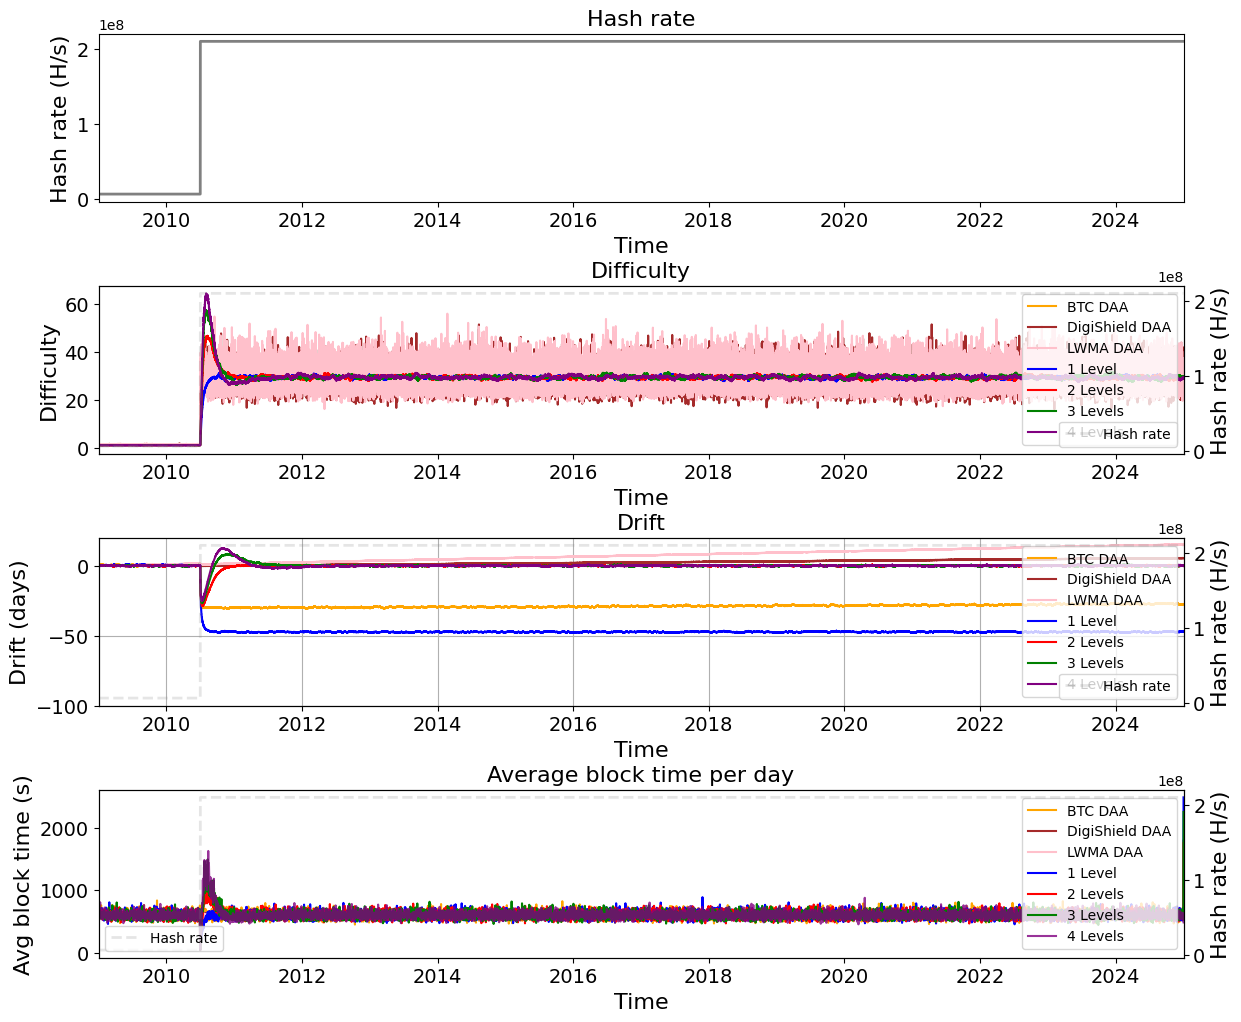

In [375]:
# start_date = pd.Timestamp('2018-10-01')
# end_date = pd.Timestamp('2019-01-01')
start_date = min(df_4_layer['median_time'])
end_date = max(df_4_layer['median_time'])
use_log = False

fig, axs = plt.subplots(4, 1, figsize=(14, 12))

# BE CAREFUL WITH THIS, DIFFERENT LAYERS MAY HAVE DIFFERENT TIME RANGES
if use_log:
    df_4_layer['log_hash_rate'] = np.log10(np.maximum(df_4_layer['real_hash_rate'].astype(float), 1e-10))
    axs[0].plot(df_4_layer['median_time'], df_4_layer['log_hash_rate'], color='gray', linewidth=2)
    axs[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
    # axs[0].plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='gray', linewidth=2)
    # axs[0].set_yscale("log")
    axs[0].set_ylabel('Hash rate (H/s)\n(log scale)', fontsize=16)
else:
    axs[0].plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='gray', linewidth=2)
    axs[0].set_ylabel('Hash rate (H/s)', fontsize=16)
axs[0].set_xlabel('Time', fontsize=16)
axs[0].set_title('Hash rate', fontsize=16)
axs[0].set_xlim(start_date, end_date)
axs[0].tick_params(axis='both', which='major', labelsize=14)

ax2_1 = axs[1].twinx()
ax2_2 = axs[2].twinx()
ax2_3 = axs[3].twinx()

# DIFFICULTY Plot data on axs[1] and ax2_1
if use_log:
    df_btc['log_difficulty'] = np.log10(np.maximum(df_btc['difficulty'].astype(float), 1e-10))
    df_digishield['log_difficulty'] = np.log10(np.maximum(df_digishield['difficulty'].astype(float), 1e-10))
    df_lwma['log_difficulty'] = np.log10(np.maximum(df_lwma['difficulty'].astype(float), 1e-10))
    df_1_layer['log_difficulty'] = np.log10(np.maximum(df_1_layer['difficulty'].astype(float), 1e-10))
    df_2_layer['log_difficulty'] = np.log10(np.maximum(df_2_layer['difficulty'].astype(float), 1e-10))
    df_3_layer['log_difficulty'] = np.log10(np.maximum(df_3_layer['difficulty'].astype(float), 1e-10))
    df_4_layer['log_difficulty'] = np.log10(np.maximum(df_4_layer['difficulty'].astype(float), 1e-10))
    axs[1].plot(df_btc['median_time'], df_btc['log_difficulty'], color='orange', label='BTC DAA')
    axs[1].plot(df_digishield['median_time'], df_digishield['log_difficulty'], color='brown', label='DigiShield DAA')
    axs[1].plot(df_lwma['median_time'], df_lwma['log_difficulty'], color='pink', label='LWMA DAA')
    axs[1].plot(df_1_layer['median_time'], df_1_layer['log_difficulty'], color='blue', label='1 Level')
    axs[1].plot(df_2_layer['median_time'], df_2_layer['log_difficulty'], color='red', label='2 Levels')
    axs[1].plot(df_3_layer['median_time'], df_3_layer['log_difficulty'], color='green', label='3 Levels')
    axs[1].plot(df_4_layer['median_time'], df_4_layer['log_difficulty'], color='purple', label='4 Levels')
    axs[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
    axs[1].set_ylabel('Difficulty\n(log scale)', fontsize=16)
else:
    axs[1].plot(df_btc['median_time'], df_btc['difficulty'], color='orange', label='BTC DAA')
    axs[1].plot(df_digishield['median_time'], df_digishield['difficulty'], color='brown', label='DigiShield DAA')
    axs[1].plot(df_lwma['median_time'], df_lwma['difficulty'], color='pink', label='LWMA DAA')
    axs[1].plot(df_1_layer['median_time'], df_1_layer['difficulty'], color='blue', label='1 Level')
    axs[1].plot(df_2_layer['median_time'], df_2_layer['difficulty'], color='red', label='2 Levels')
    axs[1].plot(df_3_layer['median_time'], df_3_layer['difficulty'], color='green', label='3 Levels')
    axs[1].plot(df_4_layer['median_time'], df_4_layer['difficulty'], color='purple', label='4 Levels')
    axs[1].set_ylabel('Difficulty', fontsize=16)
axs[1].set_xlabel('Time', fontsize=16)
axs[1].set_title('Difficulty', fontsize=16)
axs[1].tick_params(axis='both', which='major', labelsize=14)
axs[1].legend(loc='center right')
axs[1].set_xlim(start_date, end_date)
if use_log:
    ax2_1.plot(df_4_layer['median_time'], df_4_layer['log_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
    ax2_1.set_ylabel('Hash rate (H/s)\n(log scale)', fontsize=16)
    ax2_1.yaxis.set_major_formatter(ticker.StrMethodFormatter("$10^{{{x:.0f}}}$")) 
else:
    ax2_1.plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
    ax2_1.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_1.tick_params(axis='both', which='major', labelsize=14)
ax2_1.legend(loc='lower right')

# DRIFT Plot data on axs[2] and ax2_2
axs[2].plot(df_btc['median_time'], df_btc['skew'] * 14, color='orange', label='BTC DAA')
axs[2].plot(df_digishield['median_time'], df_digishield['skew'] * 14, color='brown', label='DigiShield DAA')
axs[2].plot(df_lwma['median_time'], df_lwma['skew'] * 14, color='pink', label='LWMA DAA')
axs[2].plot(df_1_layer['median_time'], df_1_layer['skew'] * 14, color='blue', label='1 Level')
axs[2].plot(df_2_layer['median_time'], df_2_layer['skew'] * 14, color='red', label='2 Levels')
axs[2].plot(df_3_layer['median_time'], df_3_layer['skew'] * 14, color='green', label='3 Levels')
axs[2].plot(df_4_layer['median_time'], df_4_layer['skew'] * 14, color='purple', label='4 Levels')
axs[2].set_title('Drift', fontsize=16)
axs[2].set_xlabel('Time', fontsize=16)
axs[2].set_ylabel('Drift (days)', fontsize=16)
axs[2].tick_params(axis='both', which='major', labelsize=14)
axs[2].legend(loc='center right')
axs[2].grid()
axs[2].set_xlim(start_date, end_date)
axs[2].set_ylim(-100, 20) # changes the scale of the y-axis
if use_log:
    ax2_2.plot(df_4_layer['median_time'], df_4_layer['log_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
    ax2_2.set_ylabel('Hash rate (H/s)\n(log scale)', fontsize=16)
    ax2_2.yaxis.set_major_formatter(ticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
else:
    ax2_2.plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
    ax2_2.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_2.tick_params(axis='both', which='major', labelsize=14)
ax2_2.legend(loc='lower right')

# AVG BLOCK TIME PER DAY Plot data on axs[3] and ax2_3
axs[3].plot(q_res_btc_avg_block_time['day'], q_res_btc_avg_block_time['avg_block_time'], color='orange', label='BTC DAA')
axs[3].plot(q_res_digishield_avg_block_time['day'], q_res_digishield_avg_block_time['avg_block_time'], color='brown', label='DigiShield DAA')
axs[3].plot(q_res_lwma_avg_block_time['day'], q_res_lwma_avg_block_time['avg_block_time'], color='pink', label='LWMA DAA')
axs[3].plot(q_res_1_layer_avg_block_time['day'], q_res_1_layer_avg_block_time['avg_block_time'], color='blue', label='1 Level')
axs[3].plot(q_res_2_layer_avg_block_time['day'], q_res_2_layer_avg_block_time['avg_block_time'], color='red', label='2 Levels')
axs[3].plot(q_res_3_layer_avg_block_time['day'], q_res_3_layer_avg_block_time['avg_block_time'], color='green', label='3 Levels')
axs[3].plot(q_res_4_layer_avg_block_time['day'], q_res_4_layer_avg_block_time['avg_block_time'], color='purple', label='4 Levels', alpha=0.8)
axs[3].set_title('Average block time per day', fontsize=16)
axs[3].set_xlabel('Time', fontsize=16)
axs[3].set_ylabel('Avg block time (s)', fontsize=16)
axs[3].tick_params(axis='both', which='major', labelsize=14)
axs[3].legend(loc='center right')
axs[3].set_xlim(start_date, end_date)
if use_log:
    ax2_3.plot(df_4_layer['median_time'], df_4_layer['log_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
    ax2_3.set_ylabel('Hash rate (H/s)\n(log scale)', fontsize=16)
    ax2_3.yaxis.set_major_formatter(ticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
else:
    ax2_3.plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
    ax2_3.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_3.tick_params(axis='both', which='major', labelsize=14)
ax2_3.legend(loc='lower left')

plt.subplots_adjust(hspace=0.5)
plt.show()

### Virtual Difficulties

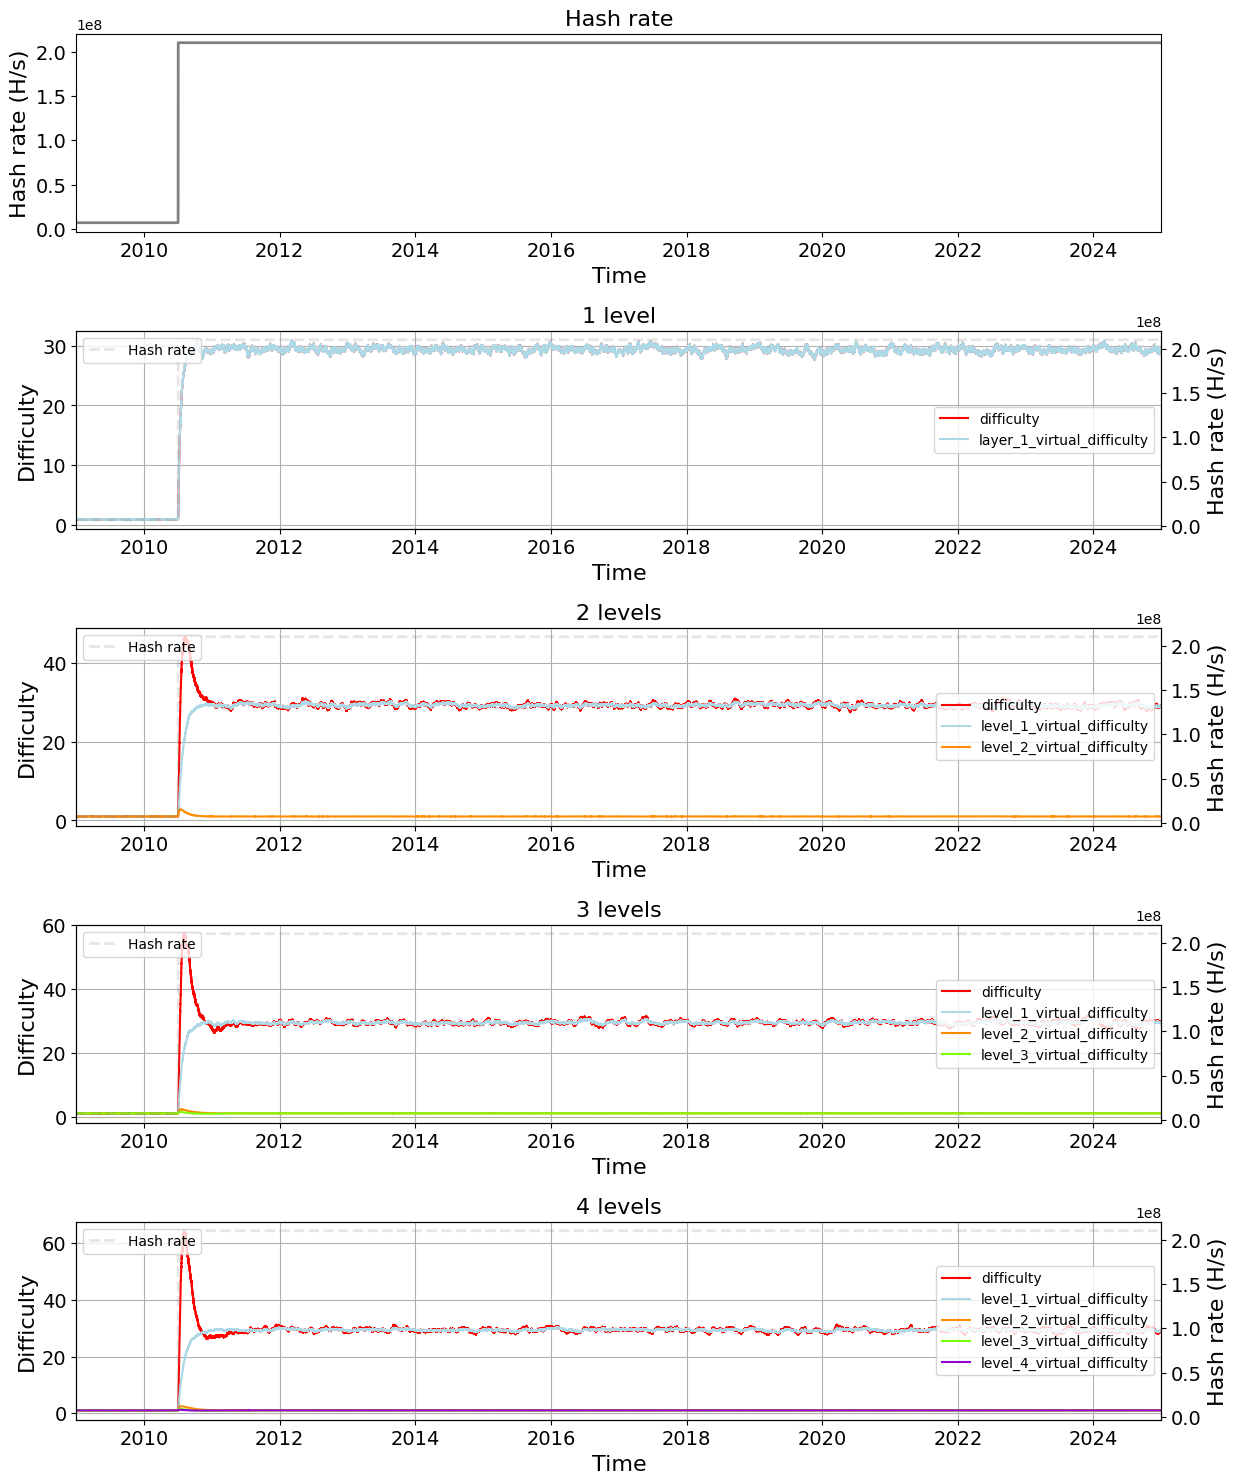

In [370]:
# start_date = pd.Timestamp('2010-01-01')
# end_date = pd.Timestamp('2012-01-01')
start_date = min(df_2_layer['median_time'])
end_date = max(df_2_layer['median_time'])

fig, axs = plt.subplots(5, 1, figsize=(14, 18))

# BE CAREFUL WITH THIS, DIFFERENT LAYERS MAY HAVE DIFFERENT TIME RANGES
axs[0].plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='gray', linewidth=2)
axs[0].set_title('Hash rate', fontsize=16)
axs[0].set_xlabel('Time', fontsize=16)
axs[0].set_ylabel('Hash rate (H/s)', fontsize=16)
axs[0].set_xlim(start_date, end_date)
axs[0].tick_params(axis='both', which='major', labelsize=14)
# axs[0].set_ylim(-1, pow(10,10)) # changes the scale of the y-axis

ax2_1 = axs[1].twinx()
ax2_2 = axs[2].twinx()
ax2_3 = axs[3].twinx()
ax2_4 = axs[4].twinx()

# axs[1].set_yscale('log')
axs[1].plot(df_1_layer['median_time'], df_1_layer['difficulty'], color='red', label='difficulty')
axs[1].plot(df_1_layer['median_time'], df_1_layer['layer_1_virtual_difficulty'], color='lightblue', label='layer_1_virtual_difficulty')
axs[1].set_title('1 level', fontsize=16)
axs[1].set_xlabel('Time', fontsize=16)
axs[1].set_ylabel('Difficulty', fontsize=16)
axs[1].tick_params(axis='both', which='major', labelsize=14)
axs[1].legend(loc='center right')
axs[1].grid()
axs[1].set_xlim(start_date, end_date)
# axs[1].set_ylim(-100, 15) # changes the scale of the y-axis
ax2_1.plot(df_1_layer['median_time'], df_1_layer['real_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
ax2_1.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_1.tick_params(axis='both', which='major', labelsize=14)
ax2_1.legend(loc='upper left')
# axs[1].set_ylim(-1, pow(10,3)) # changes the scale of the y-axis
# ax2_1.set_ylim(-1, pow(10,10)) # changes the scale of the y-axis

# axs[2].set_yscale('log')
axs[2].plot(df_2_layer['median_time'], df_2_layer['difficulty'], color='red', label='difficulty')
axs[2].plot(df_2_layer['median_time'], df_2_layer['layer_1_virtual_difficulty'], color='lightblue', label='level_1_virtual_difficulty')
axs[2].plot(df_2_layer['median_time'], df_2_layer['layer_2_virtual_difficulty'], color='darkorange', label='level_2_virtual_difficulty')
axs[2].set_title('2 levels', fontsize=16)
axs[2].set_xlabel('Time', fontsize=16)
axs[2].set_ylabel('Difficulty', fontsize=16)
axs[2].tick_params(axis='both', which='major', labelsize=14)
axs[2].legend(loc='center right')
axs[2].grid()
axs[2].set_xlim(start_date, end_date)
# axs[2].set_ylim(-100, 15) # changes the scale of the y-axis
ax2_2.plot(df_2_layer['median_time'], df_2_layer['real_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
ax2_2.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_2.tick_params(axis='both', which='major', labelsize=14)
ax2_2.legend(loc='upper left')
# axs[2].set_ylim(-1, pow(10,3)) # changes the scale of the y-axis
# ax2_2.set_ylim(-1, pow(10,10)) # changes the scale of the y-axis

# axs[3].set_yscale('log')
axs[3].plot(df_3_layer['median_time'], df_3_layer['difficulty'], color='red', label='difficulty')
axs[3].plot(df_3_layer['median_time'], df_3_layer['layer_1_virtual_difficulty'], color='lightblue', label='level_1_virtual_difficulty')
axs[3].plot(df_3_layer['median_time'], df_3_layer['layer_2_virtual_difficulty'], color='darkorange', label='level_2_virtual_difficulty')
axs[3].plot(df_3_layer['median_time'], df_3_layer['layer_3_virtual_difficulty'], color='lawngreen', label='level_3_virtual_difficulty')
axs[3].set_title('3 levels', fontsize=16)
axs[3].set_xlabel('Time', fontsize=16)
axs[3].set_ylabel('Difficulty', fontsize=16)
axs[3].tick_params(axis='both', which='major', labelsize=14)
axs[3].legend(loc='center right')
axs[3].grid()
axs[3].set_xlim(start_date, end_date)
# axs[2].set_ylim(-100, 15) # changes the scale of the y-axis
ax2_3.plot(df_3_layer['median_time'], df_3_layer['real_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
ax2_3.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_3.tick_params(axis='both', which='major', labelsize=14)
ax2_3.legend(loc='upper left')
# axs[3].set_ylim(-1, pow(10,3)) # changes the scale of the y-axis
# ax2_3.set_ylim(-1, pow(10,10)) # changes the scale of the y-axis

# axs[4].set_yscale('log')
axs[4].plot(df_4_layer['median_time'], df_4_layer['difficulty'], color='red', label='difficulty')
axs[4].plot(df_4_layer['median_time'], df_4_layer['layer_1_virtual_difficulty'], color='lightblue', label='level_1_virtual_difficulty')
axs[4].plot(df_4_layer['median_time'], df_4_layer['layer_2_virtual_difficulty'], color='darkorange', label='level_2_virtual_difficulty')
axs[4].plot(df_4_layer['median_time'], df_4_layer['layer_3_virtual_difficulty'], color='lawngreen', label='level_3_virtual_difficulty')
axs[4].plot(df_4_layer['median_time'], df_4_layer['layer_4_virtual_difficulty'], color='darkviolet', label='level_4_virtual_difficulty')
axs[4].set_title('4 levels', fontsize=16)
axs[4].set_xlabel('Time', fontsize=16)
axs[4].set_ylabel('Difficulty', fontsize=16)
axs[4].tick_params(axis='both', which='major', labelsize=14)
axs[4].legend(loc='center right')
axs[4].grid()
axs[4].set_xlim(start_date, end_date)
# axs[4].set_ylim(-100, 15) # changes the scale of the y-axis
ax2_4.plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='gray', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
ax2_4.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_4.tick_params(axis='both', which='major', labelsize=14)
ax2_4.legend(loc='upper left')
# axs[4].set_ylim(-1, pow(10,3)) # changes the scale of the y-axis
# ax2_4.set_ylim(-1, pow(10,10)) # changes the scale of the y-axis

plt.subplots_adjust(hspace=0.5)
plt.show()

### Layer explanation

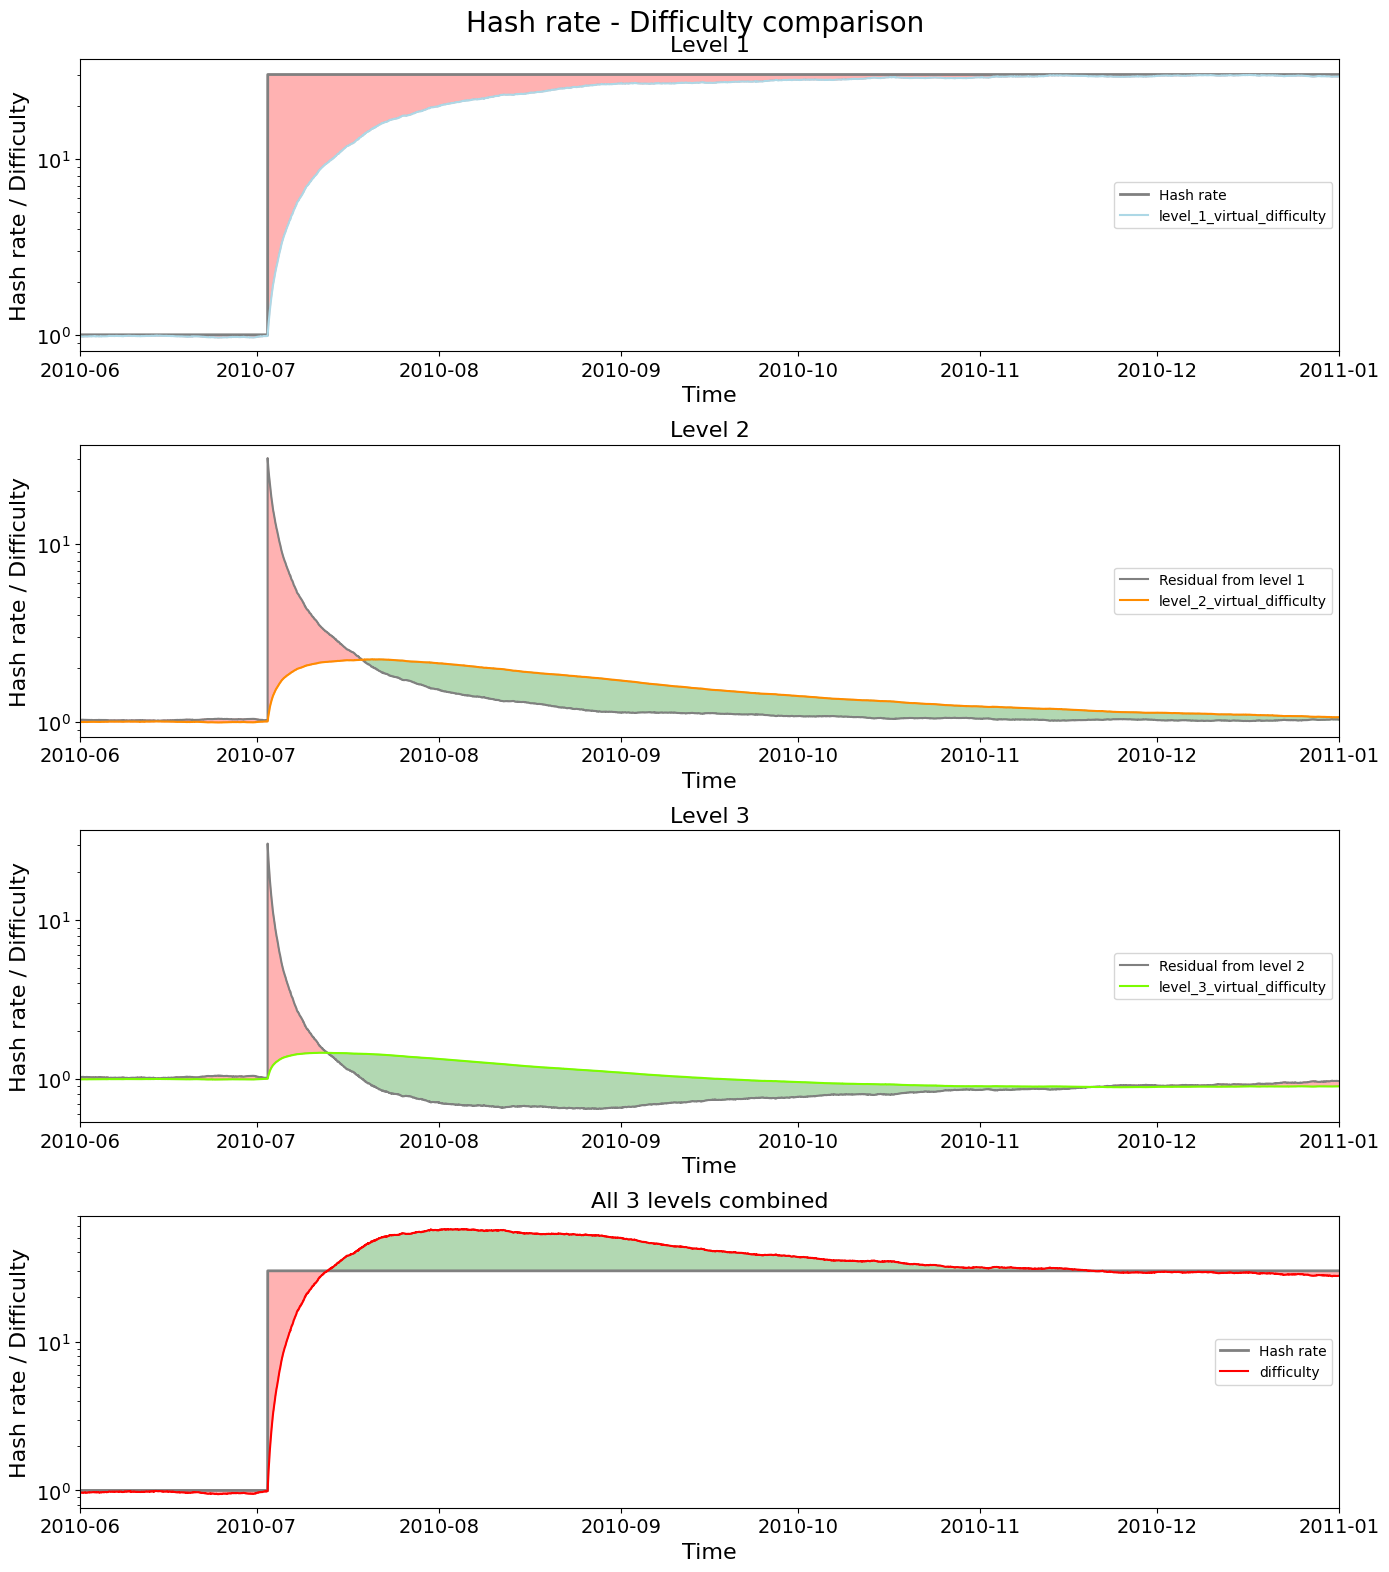

In [371]:
start_date = pd.Timestamp('2010-6-1')
end_date = pd.Timestamp('2011-1-1')

fig, ax = plt.subplots(4, figsize=(14, 16))

df_3_layer['real_hash_rate'] = pd.to_numeric(
    df_3_layer['real_hash_rate'], 
    errors='coerce' # Converts problematic strings to NaN
)

ax[0].plot(df_3_layer['median_time'], df_3_layer['real_hash_rate'] / 7000000, color='gray', label='Hash rate', linewidth=2)
ax[0].plot(df_3_layer['median_time'], df_3_layer['layer_1_virtual_difficulty'], color='lightblue', label='level_1_virtual_difficulty')
ax[0].set_yscale('log')
ax[0].set_title('Level 1', fontsize=16)
ax[0].set_xlabel('Time', fontsize=16)
ax[0].set_ylabel('Hash rate / Difficulty', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].legend(loc='center right')
ax[0].set_xlim(start_date, end_date)
ax[0].fill_between(
    df_3_layer['median_time'],                           
    df_3_layer['layer_1_virtual_difficulty'],                     
    df_3_layer['real_hash_rate'] / 7000000,                      
    where=(df_3_layer['real_hash_rate'] / 7000000 > df_3_layer['layer_1_virtual_difficulty']),    
    color='red',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)

ax[1].plot(df_3_layer['median_time'], (df_3_layer['real_hash_rate'] / (7000000 * df_3_layer['layer_1_virtual_difficulty'])), color='gray', label='Residual from level 1')
ax[1].plot(df_3_layer['median_time'], df_3_layer['layer_2_virtual_difficulty'], color='darkorange', label='level_2_virtual_difficulty')
ax[1].set_yscale('log')
ax[1].set_title('Level 2', fontsize=16)
ax[1].set_xlabel('Time', fontsize=16)
ax[1].set_ylabel('Hash rate / Difficulty', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].legend(loc='center right')
ax[1].set_xlim(start_date, end_date)
ax[1].fill_between(
    df_3_layer['median_time'],                           
    df_3_layer['layer_2_virtual_difficulty'],                     
    df_3_layer['real_hash_rate'] / (7000000 * df_3_layer['layer_1_virtual_difficulty']),                      
    where=((df_3_layer['real_hash_rate'] / 7000000) / (df_3_layer['layer_1_virtual_difficulty']) > df_3_layer['layer_2_virtual_difficulty']),    
    color='red',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)
ax[1].fill_between(
    df_3_layer['median_time'],                           
    df_3_layer['layer_2_virtual_difficulty'],                     
    df_3_layer['real_hash_rate'] / (7000000 * df_3_layer['layer_1_virtual_difficulty']),                      
    where=((df_3_layer['real_hash_rate'] / 7000000) / (df_3_layer['layer_1_virtual_difficulty']) < df_3_layer['layer_2_virtual_difficulty']),    
    color='green',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)


ax[2].plot(df_3_layer['median_time'], (df_3_layer['real_hash_rate'] / (7000000 * df_3_layer['layer_1_virtual_difficulty'] * df_3_layer['layer_2_virtual_difficulty'])), color='gray', label='Residual from level 2')
ax[2].plot(df_3_layer['median_time'], df_3_layer['layer_3_virtual_difficulty'], color='lawngreen', label='level_3_virtual_difficulty')
ax[2].set_yscale('log')
ax[2].set_title('Level 3', fontsize=16)
ax[2].set_xlabel('Time', fontsize=16)
ax[2].set_ylabel('Hash rate / Difficulty', fontsize=16)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[2].legend(loc='center right')
ax[2].set_xlim(start_date, end_date)
ax[2].fill_between(
    df_3_layer['median_time'],                           
    df_3_layer['layer_3_virtual_difficulty'],                     
    df_3_layer['real_hash_rate'] / (7000000 * df_3_layer['layer_1_virtual_difficulty'] * df_3_layer['layer_2_virtual_difficulty']),                      
    where=(((df_3_layer['real_hash_rate'] / 7000000) / (df_3_layer['layer_1_virtual_difficulty']) / (df_3_layer['layer_2_virtual_difficulty'])) > df_3_layer['layer_3_virtual_difficulty']),    
    color='red',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)
ax[2].fill_between(
    df_3_layer['median_time'],                           
    df_3_layer['layer_3_virtual_difficulty'],                     
    df_3_layer['real_hash_rate'] / (7000000 * df_3_layer['layer_1_virtual_difficulty'] * df_3_layer['layer_2_virtual_difficulty']),                      
    where=(((df_3_layer['real_hash_rate'] / 7000000) / (df_3_layer['layer_1_virtual_difficulty']) / (df_3_layer['layer_2_virtual_difficulty'])) < df_3_layer['layer_3_virtual_difficulty']),    
    color='green',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)

ax[3].plot(df_3_layer['median_time'], df_3_layer['real_hash_rate'] / 7000000, color='gray', label='Hash rate', linewidth=2)
ax[3].plot(df_3_layer['median_time'], df_3_layer['difficulty'], color='red', label='difficulty')
ax[3].set_yscale('log')
ax[3].set_title('All 3 levels combined', fontsize=16)
ax[3].set_xlabel('Time', fontsize=16)
ax[3].set_ylabel('Hash rate / Difficulty', fontsize=16)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[3].legend(loc='center right')
ax[3].set_xlim(start_date, end_date)
ax[3].fill_between(
    df_3_layer['median_time'],                           
    df_3_layer['difficulty'],                     
    df_3_layer['real_hash_rate'] / 7000000,                      
    where=(df_3_layer['real_hash_rate'] / 7000000 > df_3_layer['difficulty']),    
    color='red',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)
ax[3].fill_between(
    df_3_layer['median_time'],                           
    df_3_layer['difficulty'],                     
    df_3_layer['real_hash_rate'] / 7000000,                      
    where=(df_3_layer['real_hash_rate'] / 7000000 < df_3_layer['difficulty']),    
    color='green',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)

fig.suptitle('Hash rate - Difficulty comparison', fontsize=20)
plt.tight_layout()
plt.show()

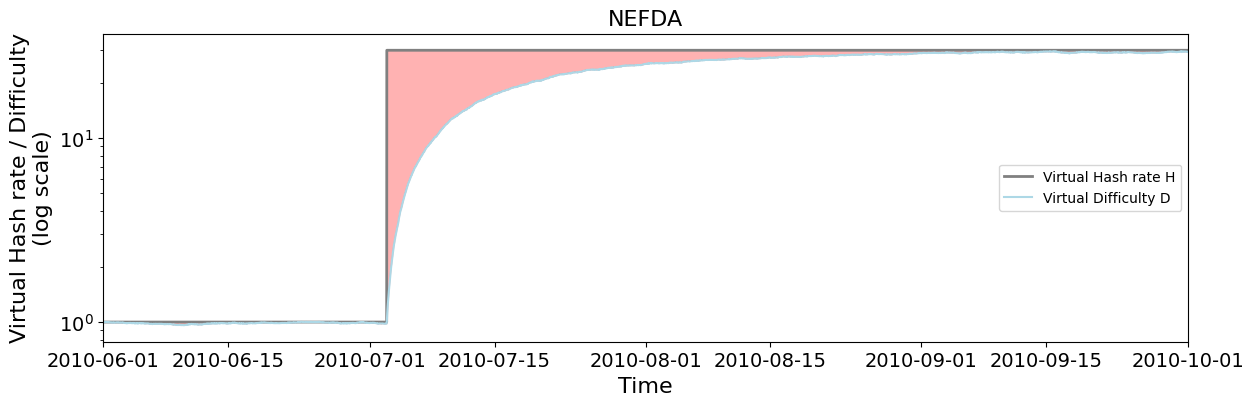

In [372]:
start_date = pd.Timestamp('2010-6-1')
end_date = pd.Timestamp('2010-10-1')

fig, ax = plt.subplots(1, figsize=(14, 4))

ax.plot(df_1_layer['median_time'], df_1_layer['real_hash_rate'] / 7000000, color='gray', label='Virtual Hash rate H', linewidth=2)
ax.plot(df_1_layer['median_time'], df_1_layer['layer_1_virtual_difficulty'], color='lightblue', label='Virtual Difficulty D')
ax.set_yscale('log')
ax.set_title('NEFDA', fontsize=16)
ax.set_xlabel('Time', fontsize=16)
ax.set_ylabel('Virtual Hash rate / Difficulty\n(log scale)', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc='center right')
ax.set_xlim(start_date, end_date)
ax.fill_between(
    df_1_layer['median_time'],                           
    df_1_layer['layer_1_virtual_difficulty'],                     
    df_1_layer['real_hash_rate'] / 7000000,                      
    where=(df_1_layer['real_hash_rate'] / 7000000 > df_1_layer['layer_1_virtual_difficulty']),    
    color='red',                
    alpha=0.3,           
    label='Hash rate > Nefda'  
)